# 📊 **APE_015: Evaluación Avanzada de Modelos: Curva ROC, Métrica AUC y Validación Cruzada (K-Fold)**

---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera


## **📌 Tarea 1: La Curva ROC y el Área Bajo la Curva (AUC)**

La Exactitud (*Accuracy*) vista en la Semana 15 depende de un umbral estático (ej. 0.5). La Curva ROC evalúa el modelo en **todos los umbrales posibles**, graficando la Tasa de Verdaderos Positivos (TPR o Sensibilidad) contra la Tasa de Falsos Positivos (FPR o $1 - \text{Especificidad}$):

1.

$$TPR = \frac{TP}{TP + FN} \quad ; \quad FPR = \frac{FP}{FP + TN}$$

Abra un nuevo Jupyter Notebook llamado APE_016_ValidacionROC.ipynb.
2. Recuperando el modelo logístico (falla de servidores) de la Semana 15, genere el siguiente código para trazar la curva ROC:

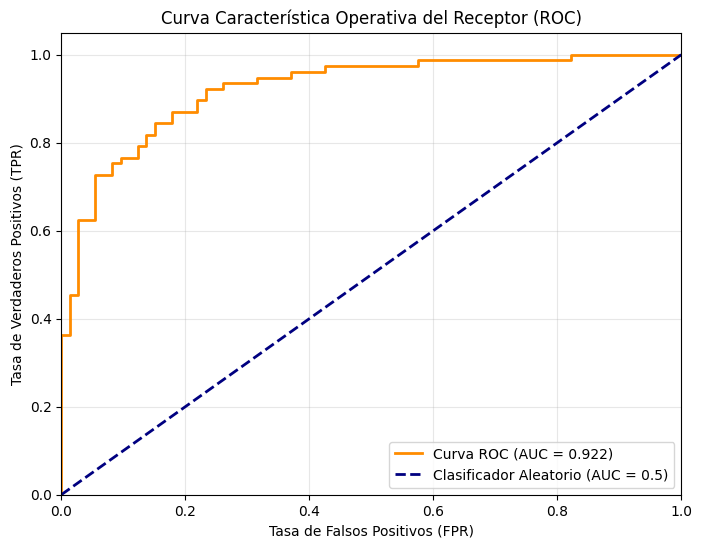


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.87      0.77      0.81        77

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simulación rápida de los datos de la Semana 15
np.random.seed(42)
temp_cpu = np.random.uniform(40, 90, 500).reshape(-1, 1) # X
z = -10 + 0.15 * temp_cpu.ravel()
prob_falla = 1 / (1 + np.exp(-z))
y_real = np.random.binomial(1, p=prob_falla) # Etiquetas (0 o 1)

# División en Entrenamiento y Prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(temp_cpu, y_real, test_size=0.30, random_state=42)

# 2. Entrenamiento del Modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Obtener las probabilidades estimadas para la clase 1
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# 3. Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# 4. Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación con umbral por defecto (0.5)
y_pred_test = modelo.predict(X_test)
print("\n--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))

## **📌 Tarea 2: Hito Final del Proyecto - Consolidación del Modelo Regional (ABP)**

Esta tarea requiere la integración de su equipo de trabajo.

1. Abran el archivo Jupyter principal de su Proyecto Integrador.
2. Identifiquen el mejor modelo predictivo generado durante el ciclo (Regresión Lineal Múltiple de la Sem 14 o Regresión Logística de la Sem 15).
3. **Si es Clasificación (Logística):** Replique el código de la Tarea 1 para graficar la Curva ROC de su proyecto y reporte el valor AUC.
4. **Si es Regresión (Lineal):** Calcule las métricas RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error) comparando y_test con y_pred_test.
5. Redacten un párrafo ejecutivo (formato Markdown) que sintetice la utilidad del modelo: *¿Es este modelo lo suficientemente preciso como para ser implementado en una empresa o institución de Loja?*

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Cargar el dataset real de la provincia de Loja
df = pd.read_csv('/content/datos_loja2 (1).csv')

# 2. Crear la variable objetivo (% de viviendas sin alcantarillado)
df['Pct_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100

# 3. Definición de variables
X = df[['Poblacion', 'Viviendas']]
y = df['Pct_Sin_Alcantarillado']

# 4. División Train / Test (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 5. Ajuste del Modelo de Regresión Lineal
modelo_reg = LinearRegression()
modelo_reg.fit(X_train, y_train)

# 6. Predicciones en el conjunto de prueba
y_pred_test = modelo_reg.predict(X_test)

# 7. Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- Evaluación del Modelo Regional (16 Cantones de Loja) ---")
print(f"Error Absoluto Medio (MAE): {mae:.2f}%")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}%")

--- Evaluación del Modelo Regional (16 Cantones de Loja) ---
Error Absoluto Medio (MAE): 18.26%
Raíz del Error Cuadrático Medio (RMSE): 35.74%


### **Viabilidad del Modelo de Cobertura de Alcantarillado en Loja**

El modelo de **Regresión Lineal Múltiple** desarrollado para estimar el **porcentaje de viviendas sin alcantarillado** en los 16 cantones de la provincia de Loja obtuvo un **Error Absoluto Medio (MAE) de 18.26 %** y una **Raíz del Error Cuadrático Medio (RMSE) de 35.74 %**. Estos resultados indican que el modelo presenta una capacidad predictiva moderada, aunque aún genera errores considerables en algunas predicciones.

**¿Es este modelo lo suficientemente preciso como para ser implementado en una empresa o institución de Loja?**

Actualmente **no se recomienda su implementación directa como herramienta única para la toma de decisiones**, ya que el nivel de error obtenido puede afectar la precisión de las estimaciones. Una posible explicación es la **heterogeneidad existente entre los cantones** de la provincia, lo que dificulta que un único modelo represente adecuadamente todos los casos.

Para mejorar su desempeño, se recomienda **segmentar el análisis** según las características de los cantones e **incorporar variables adicionales**, como indicadores socioeconómicos, inversión pública o nivel de urbanización. De esta manera, el modelo podría convertirse en una herramienta de apoyo para instituciones como los **Gobiernos Autónomos Descentralizados (GAD)** en la planificación y priorización de proyectos de infraestructura.

## **📌 Tarea 3: Preparación de Visualizaciones para la Casa Abierta**

Para la presentación de la Semana 17, el código crudo no es suficiente; se requiere comunicación efectiva.

1. Construya al menos **dos gráficos de alto impacto visual** utilizando seaborn que resuman el problema regional y la solución predictiva.
2. Limpie su Notebook: elimine celdas de pruebas fallidas, estructure con títulos #, ##, y asegúrese de que el flujo de lectura ($\text{Data Cleaning} \rightarrow \text{EDA} \rightarrow \text{Modeling} \rightarrow \text{Evaluation}$) sea lógico y profesional.

/tmp/ipykernel_962/273733193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


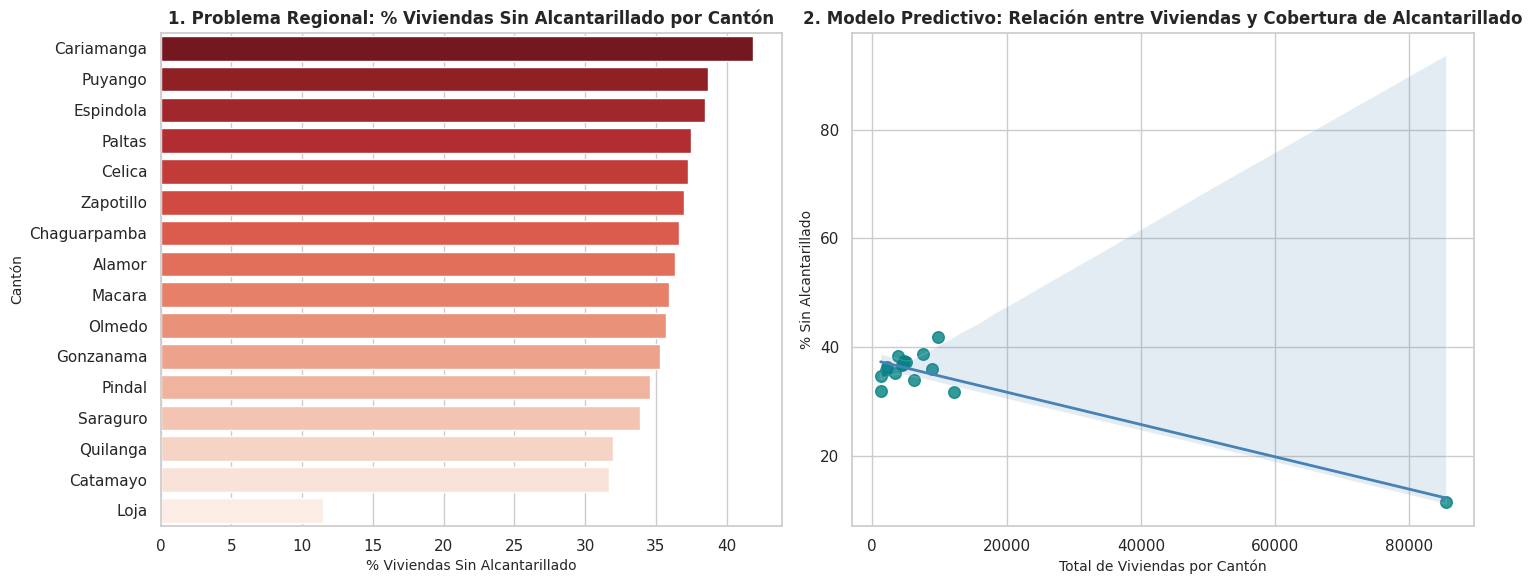

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos reales de la provincia de Loja
df = pd.read_csv('/content/datos_loja2 (1).csv')
df['Pct_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100

# 2. Configuración de estilo para la Casa Abierta
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: El Problema Regional (Déficit por Cantón)
sns.barplot(
    data=df.sort_values('Pct_Sin_Alcantarillado', ascending=False),
    x='Pct_Sin_Alcantarillado',
    y='Canton',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('1. Problema Regional: % Viviendas Sin Alcantarillado por Cantón', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% Viviendas Sin Alcantarillado', fontsize=10)
axes[0].set_ylabel('Cantón', fontsize=10)

# Gráfico 2: La Solución Predictiva (Regresión y Tendencia)
sns.regplot(
    data=df,
    x='Viviendas',
    y='Pct_Sin_Alcantarillado',
    ax=axes[1],
    color='teal',
    scatter_kws={'s': 70, 'alpha': 0.8},
    line_kws={'linewidth': 2, 'color': 'steelblue'}

)
axes[1].set_title('2. Modelo Predictivo: Relación entre Viviendas y Cobertura de Alcantarillado', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total de Viviendas por Cantón', fontsize=10)
axes[1].set_ylabel('% Sin Alcantarillado', fontsize=10)

plt.tight_layout()
plt.show()

## **📌 Tarea 4: ABI - Validación Cruzada Estocástica (K-Fold Cross Validation)**

El train_test_split es peligroso: dependiendo de la semilla aleatoria (random_state), el modelo puede parecer excelente o terrible por pura suerte probabilística.

---

1. **Investigue el concepto de $K$-Fold Cross Validation. Investigar**

K-Fold Cross Validation es una técnica de validación utilizada para evaluar el rendimiento de un modelo de aprendizaje automático. Consiste en dividir el conjunto de datos en $K$ subconjuntos (*folds*) de tamaño similar. En cada iteración, uno de los subconjuntos se utiliza para validar el modelo y los restantes para entrenarlo. Este proceso se repite hasta que todos los subconjuntos hayan sido utilizados como conjunto de prueba una vez. Finalmente, se calcula el promedio de las métricas obtenidas, proporcionando una estimación más estable y confiable del desempeño del modelo y reduciendo el riesgo de sobreajuste.

---

2. **Ejecute el siguiente código para dividir su set de entrenamiento simulado en 5 "dobleces" (Folds) y calcular el rendimiento promedio.**

In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Ejecutar validación cruzada con K=5 folds
k_folds = 5

# cv requiere el modelo, los predictores (X) y las respuestas (y)
scores_auc = cross_val_score(modelo, temp_cpu, y_real, cv=k_folds, scoring='roc_auc')

# 2. Impresión de resultados
print(f"--- Análisis de Validación Cruzada (K={k_folds}) ---")
print(f"AUC de cada Fold: {np.round(scores_auc, 3)}")
print(f"AUC Promedio Estocástico (E[AUC]): {scores_auc.mean():.3f}")
print(f"Desviación Estándar (σ_AUC): ±{scores_auc.std():.3f}")

if scores_auc.std() > 0.10:
    print("Advertencia: El modelo es inestable (alta varianza entre particiones).")
else:
    print("Éxito: El modelo es estable y generaliza bien.")

--- Análisis de Validación Cruzada (K=5) ---
AUC de cada Fold: [0.888 0.906 0.908 0.929 0.934]
AUC Promedio Estocástico (E[AUC]): 0.913
Desviación Estándar (σ_AUC): ±0.017
Éxito: El modelo es estable y generaliza bien.


3.  **Aplique cross_val_score a su modelo regional del Proyecto Integrador. Documente si la desviación estándar del rendimiento le da confianza matemática para implementarlo en producción.**

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 1. Carga del dataset de Loja
df = pd.read_csv('/content/datos_loja2 (1).csv')
df['Pct_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100

X = df[['Poblacion', 'Viviendas']]
y = df['Pct_Sin_Alcantarillado']

# 2. Modelo de Regresión Lineal y K=5 Folds
modelo_lin = LinearRegression()
k_folds = 5

# 3. Validación Cruzada para MAE
scores_mae = -cross_val_score(modelo_lin, X, y, cv=k_folds, scoring='neg_mean_absolute_error')

print(f"--- Análisis de Validación Cruzada (K={k_folds}) - Proyecto Integrador ---")
print(f"MAE de cada Fold: {np.round(scores_mae, 2)}%")
print(f"MAE Promedio Estocástico (E[MAE]): {scores_mae.mean():.2f}%")
print(f"Desviación Estándar (σ_MAE): ±{scores_mae.std():.2f}%")

--- Análisis de Validación Cruzada (K=5) - Proyecto Integrador ---
MAE de cada Fold: [15.19  1.32  0.87  1.    3.74]%
MAE Promedio Estocástico (E[MAE]): 4.42%
Desviación Estándar (σ_MAE): ±5.49%


### **Interpretación: Análisis de Estabilidad mediante Validación Cruzada**

La **validación cruzada con 5 folds** mostró un **MAE promedio de 4.42 %** y una **desviación estándar de ±5.49 %**. Esto indica que el rendimiento del modelo varía entre las diferentes particiones del conjunto de datos.

Aunque el error promedio es relativamente bajo, **la desviación estándar es mayor que el promedio** debido a que uno de los folds presentó un error considerablemente superior al resto.

Por esta razón, **el modelo aún no ofrece suficiente confianza matemática para ser implementado como herramienta de producción**, especialmente porque el conjunto de datos está compuesto únicamente por **16 cantones**. Se recomienda **ampliar la base de datos** e **incorporar variables explicativas adicionales** para mejorar la estabilidad y la capacidad de generalización del modelo.

## **📌 6. Preguntas de Control:**

* **¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es ontológicamente indistinguible del azar?**

  Un clasificador con un **AUC de 0.5** no tiene capacidad para distinguir correctamente entre las clases positiva y negativa. Su desempeño es **equivalente al de realizar una predicción al azar**, ya que tiene la misma probabilidad de acertar que de equivocarse. Por ello, se considera que **no ha aprendido patrones útiles** de los datos y no aporta información confiable para la toma de decisiones.

---


* **¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en la exactitud (Accuracy), ignorando la calidad de su juicio sobre las clases minoritarias?**

  No. La **Accuracy** puede ser engañosa cuando las clases están desbalanceadas. Un modelo puede obtener una alta exactitud simplemente prediciendo siempre la clase mayoritaria, pero **fallar al identificar correctamente la clase minoritaria**. Por ello, es necesario analizar otras métricas como la **precisión**, el **recall**, el **F1-score** o el **AUC** para evaluar de forma más completa el rendimiento del modelo.

---

* **Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds), ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?**

  Si el rendimiento cambia considerablemente entre los diferentes *folds*, significa que **el modelo no es estable** y probablemente ha aprendido patrones específicos del conjunto de entrenamiento en lugar de relaciones generales. Esto indica un **posible sobreajuste (overfitting)** y reduce la confianza en su capacidad para predecir correctamente nuevos datos.

---

* **Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?**

  La validación cruzada evalúa el modelo utilizando diferentes particiones de los datos, lo que permite **conocer su comportamiento en múltiples escenarios**. De esta forma, la evaluación es **más representativa** y menos dependiente de una única división entre entrenamiento y prueba, proporcionando una **estimación más confiable de su capacidad de generalización**.

---

* **¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?**

  El **rigor estocástico** permite evaluar la incertidumbre y la variabilidad de las predicciones, mientras que el **escepticismo matemático** evita presentar conclusiones exageradas o infundadas. Esto contribuye a que las decisiones tomadas a partir de los modelos sean **más responsables, transparentes y confiables**.